In [ ]:
import sys

sys.path.append("../")

import shutil
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import Video, display

from agents.factory import build_agent
from training.config import load_experiment_config

home_path = Path.cwd().parent
video_path = home_path / "videos"

In [68]:
def visualize_checkpoint(checkpoint_path: str, config_path: str) -> None:
    config = load_experiment_config(config_path)

    base_env = gym.make(config.env.id, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(
        base_env, video_folder=str(video_path / "temp"), disable_logger=True
    )

    agent = build_agent(
        config=config,
        observation_space=env.observation_space,
        action_space=env.action_space,
    )
    agent.load(checkpoint_path)

    x_positions = []
    y_positions = []
    rewards_history = []
    timesteps = []

    obs, info = env.reset()
    done = False
    total_reward = 0.0
    step_count = 0

    while not done:
        x_positions.append(obs[0])
        y_positions.append(obs[1])

        action = agent.act(obs, explore=False)
        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        step_count += 1
        rewards_history.append(total_reward)
        timesteps.append(step_count)

        done = terminated or truncated

    env.close()

    target_video_name = f"video_{Path(checkpoint_path).stem}.mp4"
    final_video_path = video_path / target_video_name
    temp_video_path = next((video_path / "temp").glob("*.mp4"))
    shutil.move(str(temp_video_path), str(final_video_path))

    print("=" * 50 + f" Checkpoint: {Path(checkpoint_path).name} " + "=" * 50)

    # Wideo
    display(Video(final_video_path, embed=True, width=700))

    # Wykresy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(
        x_positions, y_positions, label="Ścieżka lotu", color="royalblue", linewidth=2.5
    )
    ax1.scatter(
        [0], [0], color="crimson", marker="X", s=150, zorder=5, label="Środek lądowiska"
    )

    ax1.axvspan(
        -0.2,
        0.2,
        ymin=0,
        ymax=0.05,
        color="orange",
        alpha=0.3,
        label="Strefa lądowania (Flagi)",
    )

    ax1.set_title("Trajektoria lotu (Pozycja)", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Pozycja X")
    ax1.set_ylabel("Pozycja Y")
    ax1.set_xlim(-1.0, 1.0)
    ax1.set_ylim(-0.1, 1.5)
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend(loc="upper right")

    ax2.plot(
        timesteps,
        rewards_history,
        label="Suma nagród",
        color="emerald" if total_reward > 200 else "chocolate",
        linewidth=2.5,
    )
    ax2.axhline(
        200, color="green", linestyle="--", alpha=0.7, label="Próg sukcesu (+200)"
    )
    ax2.axhline(0, color="gray", linestyle="-", alpha=0.5)

    ax2.set_title(
        f"Zmiana nagrody w czasie (Wynik końcowy: {total_reward:.2f})",
        fontsize=11,
        fontweight="bold",
    )
    ax2.set_xlabel("Krok (Timestep)")
    ax2.set_ylabel("Skumulowana nagroda")
    ax2.grid(True, linestyle=":", alpha=0.6)
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

================================================== Checkpoint: episode_00005.pt ==================================================


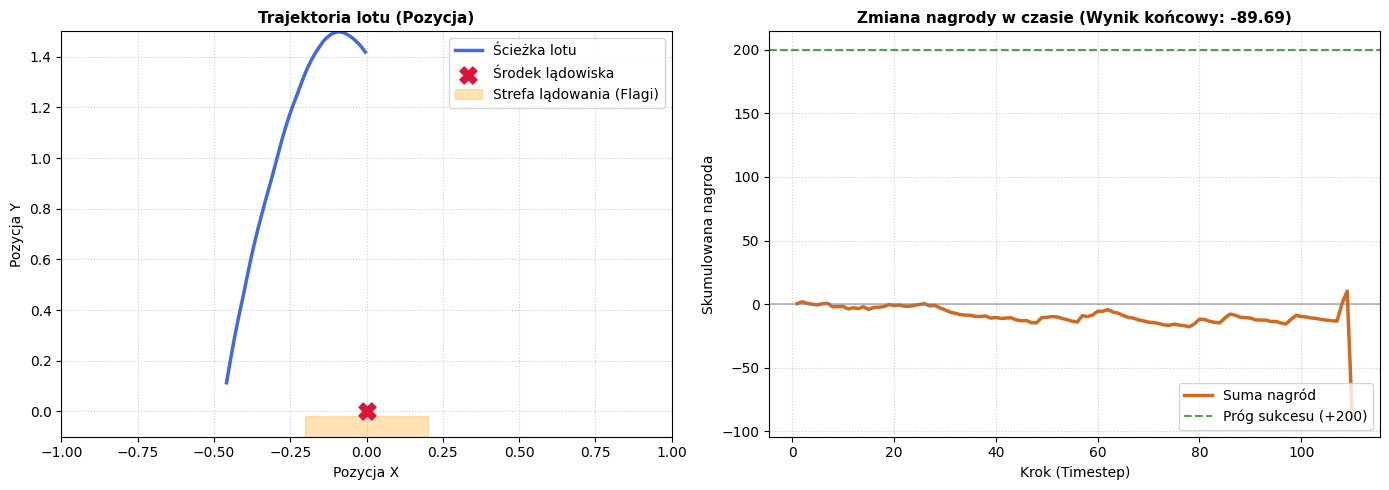

================================================== Checkpoint: episode_00500.pt ==================================================


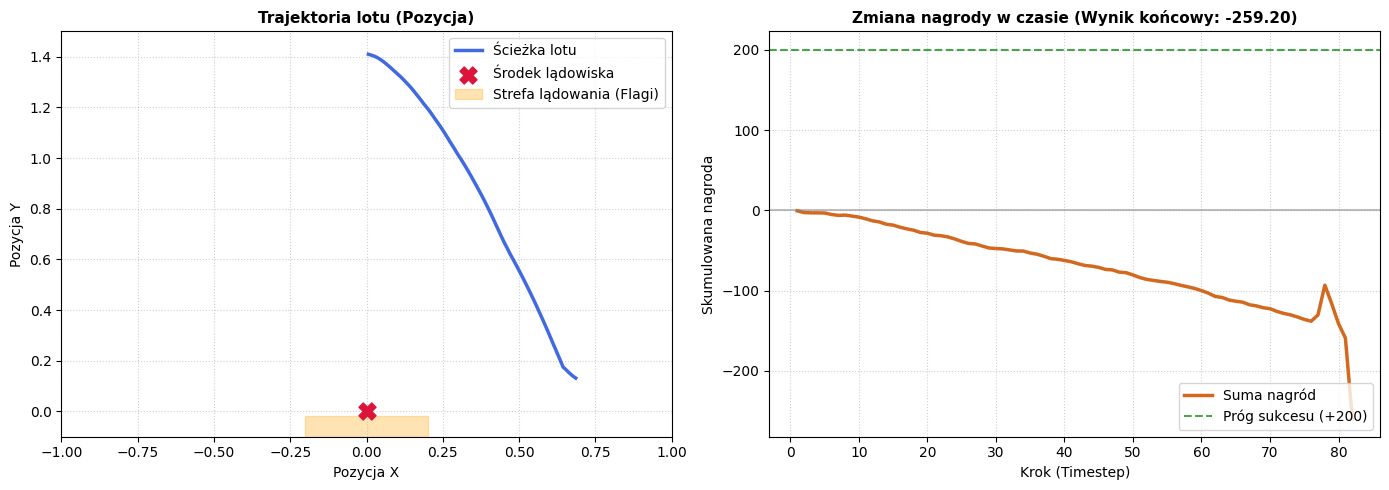

================================================== Checkpoint: best.pt ==================================================


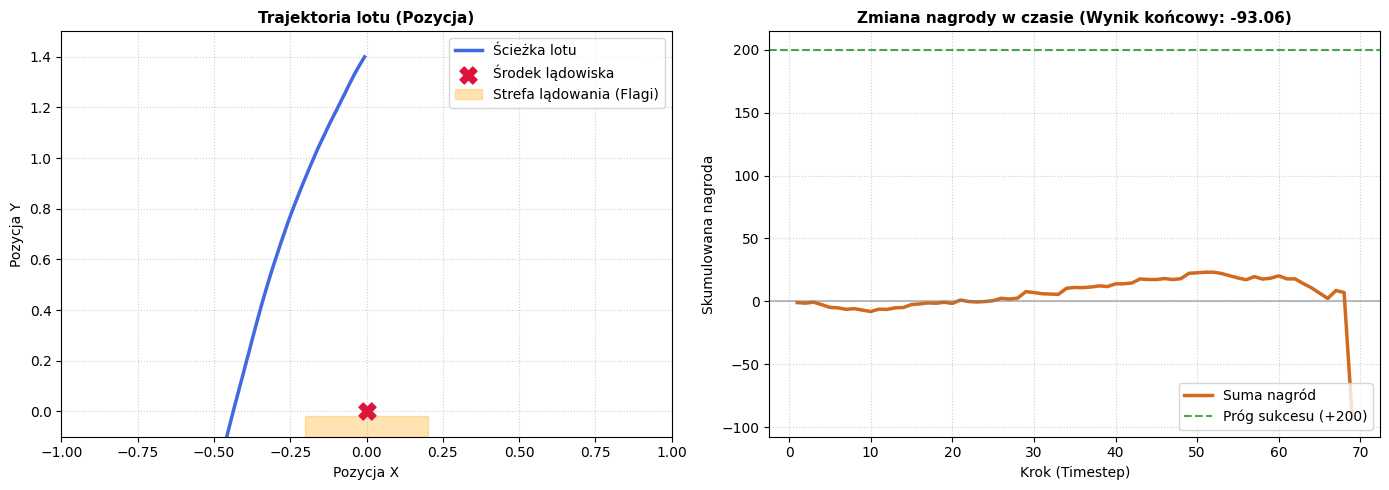

In [69]:
checkpoints = ["episode_00005.pt", "episode_00500.pt", "best.pt"]

for checkpoint in checkpoints:
    visualize_checkpoint(
        checkpoint_path=str(home_path) + "/checkpoints/" + checkpoint,
        config_path="../configs/baseline.yaml",
    )